In [1]:
import pandas as pd
df_clim = pd.read_csv("climate_indices.csv")

In [2]:
import pandas as pd

TORNADO_URL = "https://www.spc.noaa.gov/wcm/data/1950-2021_actual_tornadoes.csv"
df_tor = pd.read_csv(TORNADO_URL)
df_tor['date'] = pd.to_datetime(df_tor['date'], errors='coerce')

df_il = df_tor[df_tor['st'] == 'IL'].copy()
df_il['ym'] = pd.to_datetime(df_il['date'].dt.to_period('M').astype(str))

df_il_month = df_il.groupby('ym').size().reset_index(name='tornado_count')

In [3]:
df_clim = pd.read_csv("climate_indices.csv")
df_clim.rename(columns={"index": "date"}, inplace=True)
df_clim['date'] = pd.to_datetime(df_clim['date'])
df_clim['ym'] = pd.to_datetime(df_clim['date'].dt.to_period('M').astype(str))

In [4]:
df_all = pd.merge(
    df_il_month,
    df_clim[['ym', 'ENSO', 'PDO', 'NAO', 'AO']],
    on='ym',
    how='inner'
)

df_all = df_all.dropna().sort_values('ym').reset_index(drop=True)

In [6]:
from sklearn.ensemble import RandomForestRegressor

X = df_all.drop(columns=['tornado_count', 'ym'])
y = df_all['tornado_count']

rf = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X, y)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


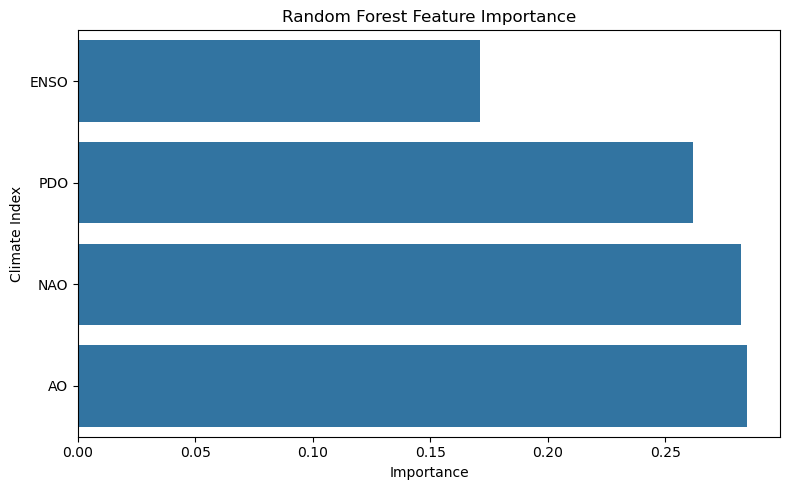

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf.feature_importances_
features = X.columns

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=features)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Climate Index")
plt.tight_layout()
plt.show()

In [8]:
#!pip install shap

 95%|=================== | 420/440 [00:14<00:00]       

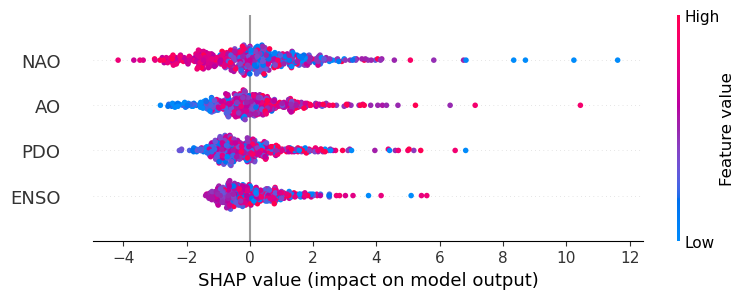

In [9]:
import shap
import matplotlib.pyplot as plt

explainer = shap.Explainer(rf, X)
shap_values = explainer(X, check_additivity=False)

shap.summary_plot(shap_values, X)

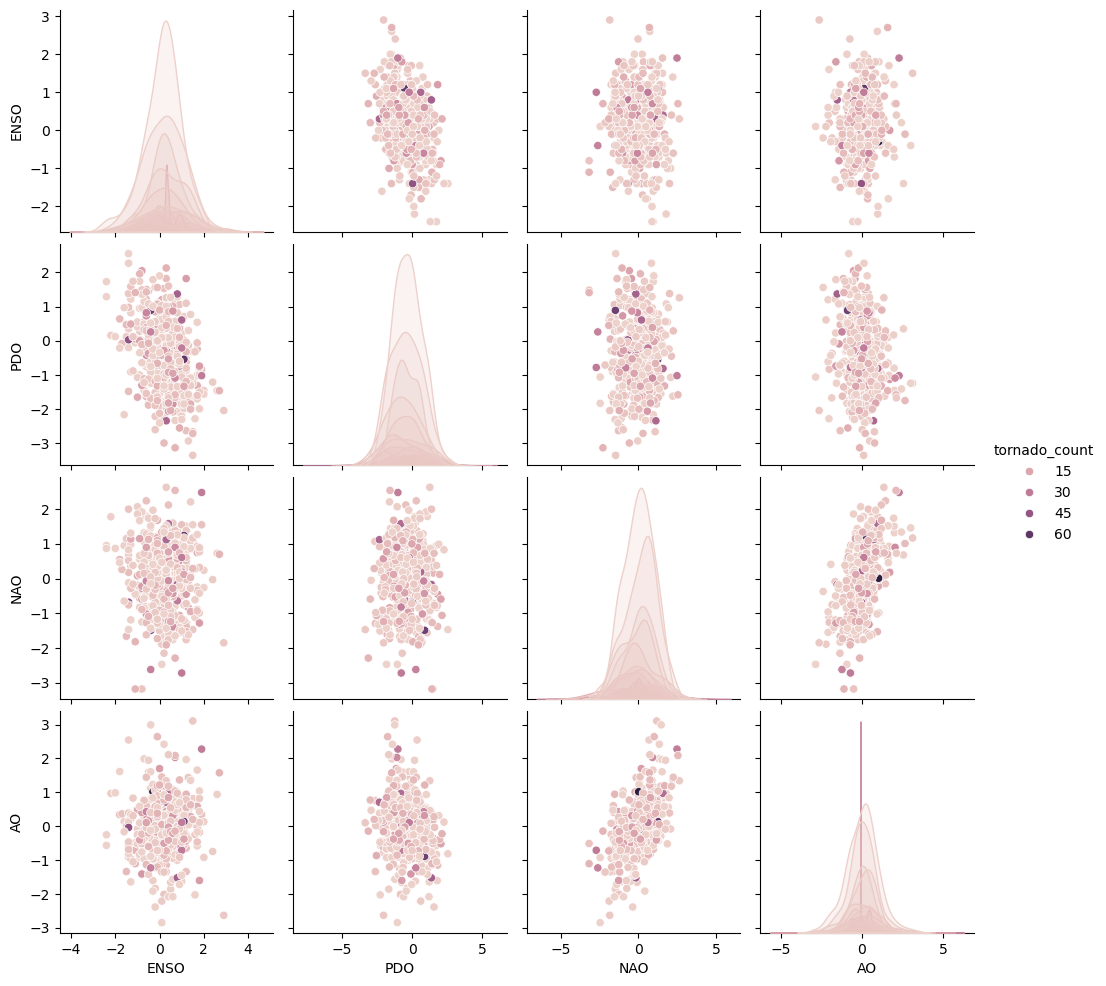

In [10]:
import seaborn as sns
sns.pairplot(df_all, vars=['ENSO','PDO','NAO','AO'], hue='tornado_count')

In [13]:
df_all['month'] = df_all['ym'].dt.month
df_all_encoded = pd.get_dummies(df_all, columns=['month'])

X_encoded = df_all_encoded.drop(columns=['tornado_count', 'ym'])
y_encoded = df_all_encoded['tornado_count']

rf_encoded = RandomForestRegressor(n_estimators=500, min_samples_leaf=2, random_state=42, n_jobs=-1)
rf_encoded.fit(X_encoded, y_encoded)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


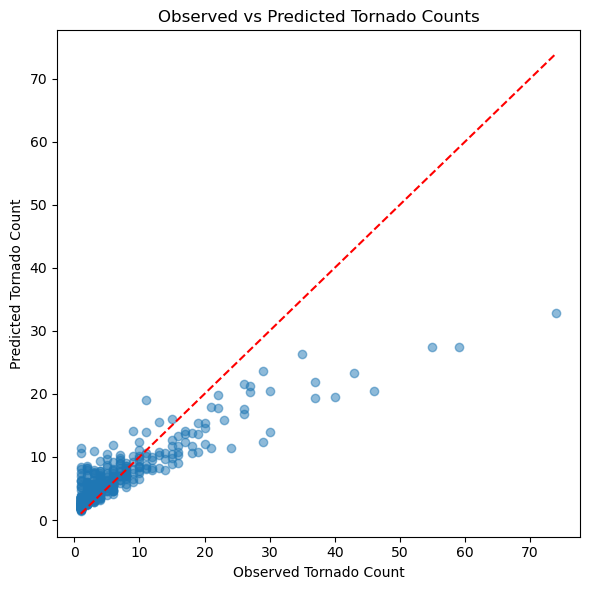

In [14]:
y_pred = rf_encoded.predict(X_encoded)

# Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_encoded, y_pred, alpha=0.5)
plt.xlabel("Observed Tornado Count")
plt.ylabel("Predicted Tornado Count")
plt.title("Observed vs Predicted Tornado Counts")
plt.plot([y_encoded.min(), y_encoded.max()], [y_encoded.min(), y_encoded.max()], 'r--')
plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_encoded, y_pred))
corr = np.corrcoef(y_encoded, y_pred)[0,1]

print(f"RMSE: {rmse:.2f}")
print(f"Correlation: {corr:.2f}")

RMSE: 4.68
Correlation: 0.90


 96%|=================== | 423/440 [00:16<00:00]       

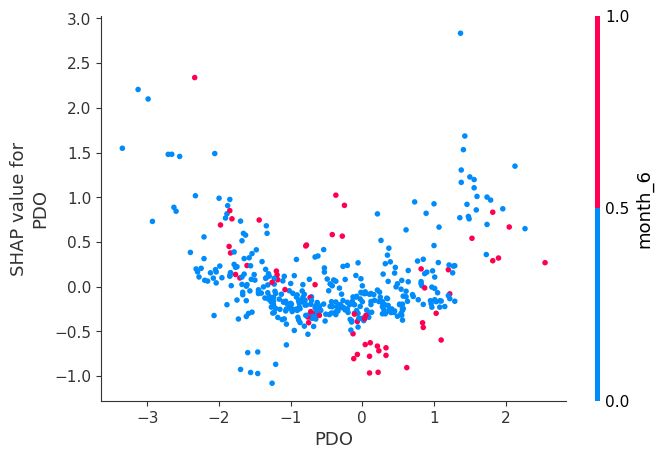

In [22]:
X_encoded = X_encoded.astype(float)
explainer_encoded = shap.Explainer(rf_encoded, X_encoded)
shap_values_encoded = explainer_encoded(X_encoded, check_additivity=False)
shap.dependence_plot("PDO", shap_values_encoded.values, X_encoded)